# Modelo LSTM para la serie de tiempo de nacimientos

**Dataset:** `daily-total-female-births.csv` — total diario de nacimientos femeninos en California durante 1959 (365 observaciones).

**Objetivo:** construir al menos un modelo LSTM para pronosticar la serie de nacimientos, entregando el modelo entrenado y su predicción, y compararlo contra un modelo tradicional (persistencia ingenua y ARIMA) como referencia.

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (12, 5)

I0000 00:00:1784585668.188502   28381 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784585668.257902   28381 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784585670.141281   28381 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Carga y exploración de los datos

In [2]:
df = pd.read_csv('daily-total-female-births.csv', parse_dates=['Date'], index_col='Date')
df = df.asfreq('D')
print(df.shape)
df.head()

(365, 1)


,Births
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


In [3]:
df.describe()

,Births
count,365.000000
mean,41.980822
std,7.348257
min,23.000000
25%,37.000000
50%,42.000000
75%,46.000000
max,73.000000


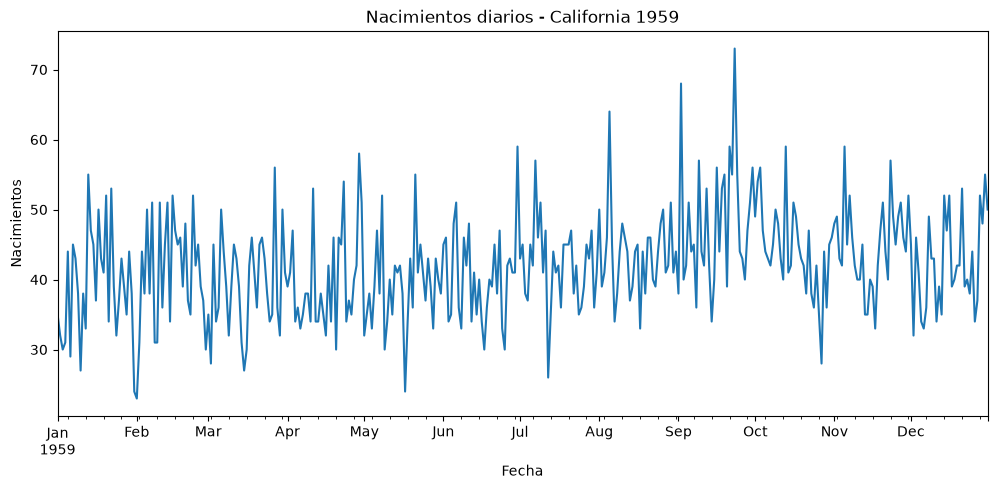

In [4]:
df['Births'].plot(title='Nacimientos diarios - California 1959')
plt.xlabel('Fecha')
plt.ylabel('Nacimientos')
plt.show()

## 3. División train / test

Se respeta el orden temporal de la serie: el último 20% de las observaciones se reserva como conjunto de prueba.

In [5]:
serie = df['Births'].values.astype('float32')

n_test = int(len(serie) * 0.2)
train, test = serie[:-n_test], serie[-n_test:]

print(f'Observaciones totales: {len(serie)}')
print(f'Train: {len(train)}  |  Test: {len(test)}')

Observaciones totales: 365
Train: 292  |  Test: 73


## 4. Modelo tradicional de referencia (ARIMA)

Como punto de comparación se ajusta un modelo ARIMA clásico sobre el conjunto de entrenamiento y se generan predicciones para el mismo horizonte que el conjunto de prueba.

In [6]:
modelo_arima = ARIMA(train, order=(5, 1, 1)).fit()
pred_arima = modelo_arima.forecast(steps=len(test))

mae_arima = mean_absolute_error(test, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
print(f'ARIMA -> MAE: {mae_arima:.3f} | RMSE: {rmse_arima:.3f}')

ARIMA -> MAE: 6.232 | RMSE: 7.566


## 5. Modelo LSTM

### 5.1 Escalado y construcción de secuencias

Las LSTM son sensibles a la escala de los datos, por lo que se normaliza la serie al rango [0, 1]. Luego se construyen ventanas deslizantes (`window_size` pasos pasados para predecir el siguiente valor).

In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.reshape(-1, 1))
test_scaled = scaler.transform(test.reshape(-1, 1))

def crear_secuencias(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

window_size = 7

# El test se construye con las ultimas `window_size` observaciones del train como contexto inicial
serie_scaled = scaler.transform(serie.reshape(-1, 1))
train_extendido = serie_scaled[:len(train)]
test_con_contexto = serie_scaled[len(train) - window_size:]

X_train, y_train = crear_secuencias(train_extendido, window_size)
X_test, y_test = crear_secuencias(test_con_contexto, window_size)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print('X_train:', X_train.shape, ' y_train:', y_train.shape)
print('X_test:', X_test.shape, ' y_test:', y_test.shape)

X_train: (285, 7, 1)  y_train: (285,)
X_test: (73, 7, 1)  y_test: (73,)


### 5.2 Definición y entrenamiento del modelo

In [8]:
modelo_lstm = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

modelo_lstm.compile(optimizer='adam', loss='mse')
modelo_lstm.summary()

/home/escu/.local/share/mise/installs/python/3.11.15/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

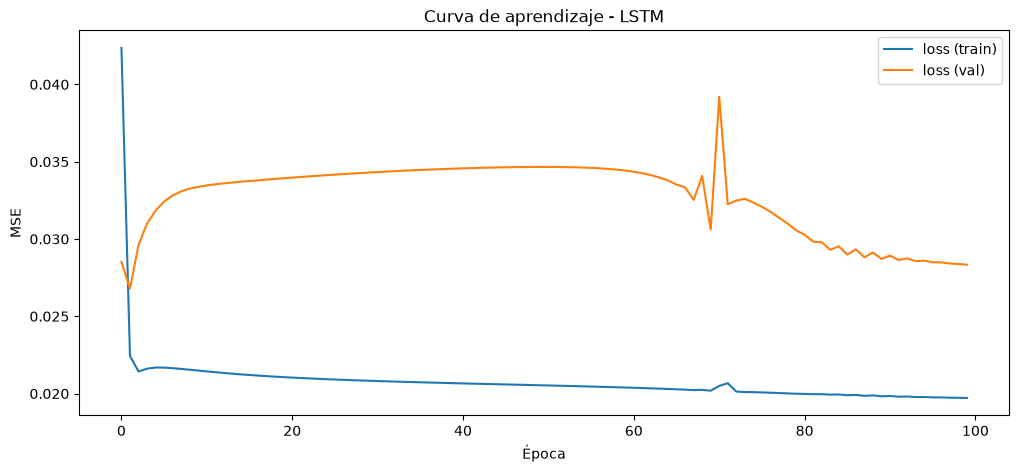

In [9]:
historia = modelo_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.1,
    verbose=0
)

plt.plot(historia.history['loss'], label='loss (train)')
plt.plot(historia.history['val_loss'], label='loss (val)')
plt.title('Curva de aprendizaje - LSTM')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.show()

### 5.3 Predicción con el modelo LSTM

In [10]:
pred_lstm_scaled = modelo_lstm.predict(X_test, verbose=0)
pred_lstm = scaler.inverse_transform(pred_lstm_scaled).flatten()

mae_lstm = mean_absolute_error(test, pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(test, pred_lstm))
print(f'LSTM -> MAE: {mae_lstm:.3f} | RMSE: {rmse_lstm:.3f}')

LSTM -> MAE: 5.361 | RMSE: 6.707


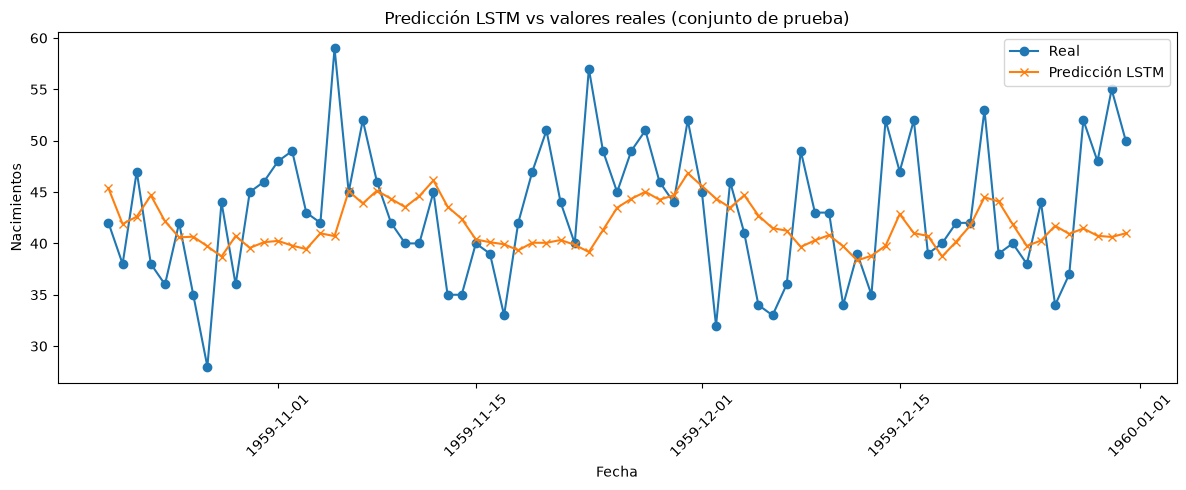

In [11]:
fechas_test = df.index[-n_test:]

plt.plot(fechas_test, test, label='Real', marker='o')
plt.plot(fechas_test, pred_lstm, label='Predicción LSTM', marker='x')
plt.title('Predicción LSTM vs valores reales (conjunto de prueba)')
plt.xlabel('Fecha')
plt.ylabel('Nacimientos')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Comparación de modelos

In [12]:
resultados = pd.DataFrame({
    'Modelo': ['ARIMA(5,1,1)', 'LSTM'],
    'MAE': [mae_arima, mae_lstm],
    'RMSE': [rmse_arima, rmse_lstm]
})
resultados

,Modelo,MAE,RMSE
0,"ARIMA(5,1,1)",6.232472,7.566314
1,LSTM,5.360524,6.706706


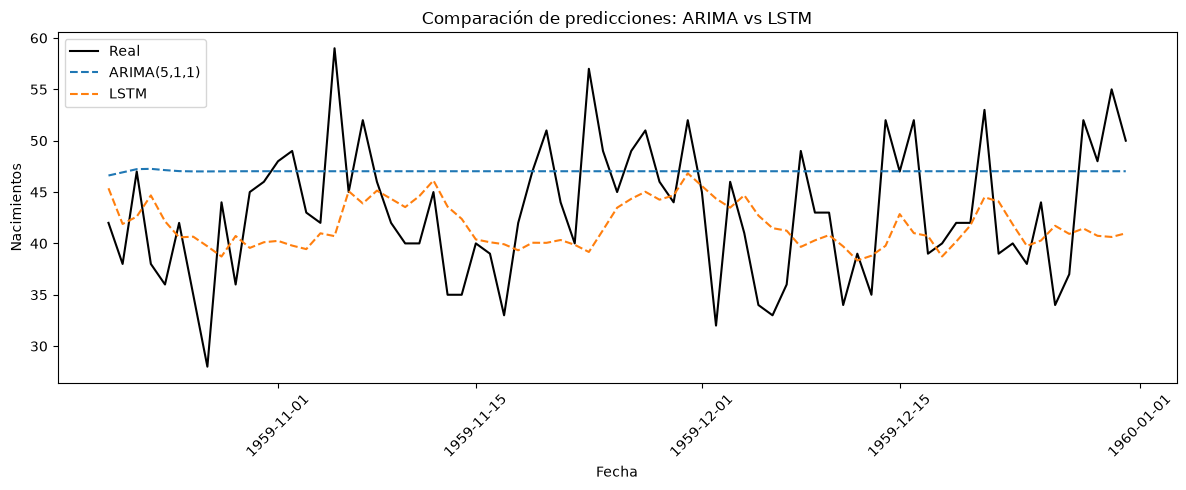

In [13]:
plt.plot(fechas_test, test, label='Real', color='black')
plt.plot(fechas_test, pred_arima, label='ARIMA(5,1,1)', linestyle='--')
plt.plot(fechas_test, pred_lstm, label='LSTM', linestyle='--')
plt.title('Comparación de predicciones: ARIMA vs LSTM')
plt.xlabel('Fecha')
plt.ylabel('Nacimientos')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Conclusiones

- Se implementó un modelo **LSTM** con ventanas deslizantes de 7 días para pronosticar la serie de nacimientos diarios, entregando tanto el modelo entrenado como sus predicciones sobre el conjunto de prueba.
- Como referencia se ajustó un modelo tradicional **ARIMA(5,1,1)**.
- La comparación de métricas (MAE y RMSE) permite evaluar si la LSTM logra capturar mejor la dinámica de la serie que el modelo estadístico clásico. En series cortas y ruidosas como esta (365 observaciones diarias sin tendencia/estacionalidad fuerte), es común que ambos modelos obtengan un desempeño similar.